Taller Regresion logistica
 riesgo de enfermedad coronaria ( necesito crear un modelo para saber si tiene riesgo de enfermedad coronaria)

**Descripción de variables**

Demographic:

Sex: male or female(Nominal)

Age: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)
Behavioral

Current Smoker: whether or not the patient is a current smoker (Nominal)

Cigs Per Day: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)
Medical( history)

BP Meds: whether or not the patient was on blood pressure medication (Nominal)

Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)

Prevalent Hyp: whether or not the patient was hypertensive (Nominal)

Diabetes: whether or not the patient had diabetes (Nominal) Medical(current)

Tot Chol: total cholesterol level (Continuous)

Sys BP: systolic blood pressure (Continuous)

Dia BP: diastolic blood pressure (Continuous)

BMI: Body Mass Index (Continuous)

Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)

Glucose: glucose level (Continuous) Predict variable (desired target)

10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd
path= '/content/drive/MyDrive/Aprendizaje supervisado para el pronostico/framingham.xls'
df= pd.read_csv(path)
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [44]:
#aca estoy verificando si cuando dice que una persona no fuma tambien aparece que fuma 0 cigarrillos
all_non_smokers_have_zero_cigs = (df[df['currentSmoker'] == 0]['cigsPerDay'] == 0.0).all()
display(all_non_smokers_have_zero_cigs)

np.True_

Revisar si hay valores vacios en las variables

In [45]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
display(missing_values)

,0
education,105
cigsPerDay,29
BPMeds,53
totChol,50
BMI,19
heartRate,1
glucose,388


In [46]:
# Eliminar filas con valores faltantes del DataFrame original
df_cleaned = df.dropna()


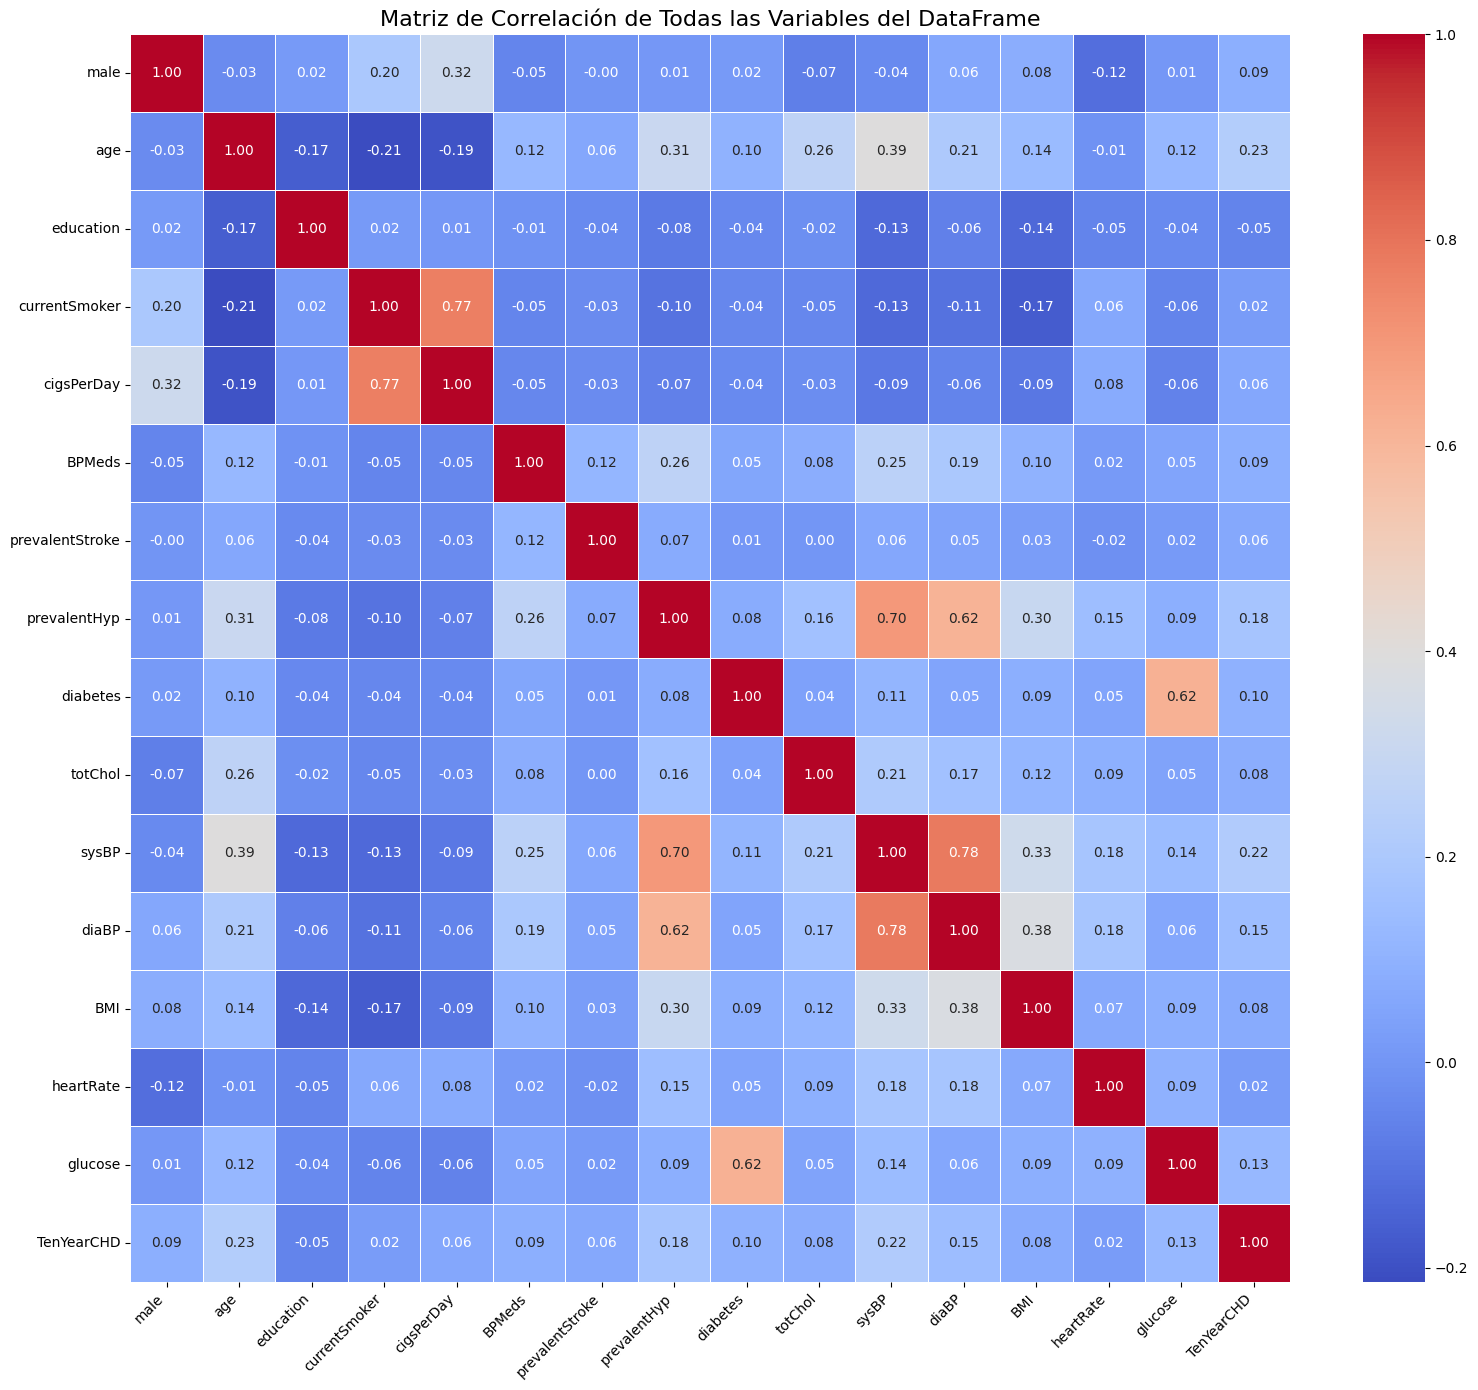

In [47]:
overall_corr_matrix = df.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(overall_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Todas las Variables del DataFrame', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

las variables que mas correlacion tienen son:

* current smoker y cigarettes per day
*  diabetes and glucose
*  prevalent HYP and sysBP
* prevalent HYP and diaBP
*  sysBP and diaBP
* glucose and diabetes








Modelo de regresion logistica

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Import SimpleImputer


X = df.drop(['TenYearCHD'], axis=1)
y = df['TenYearCHD']

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputación de valores faltantes
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Datos escalados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Modelo de regresion logistica
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train_scaled, y_train)

# Prediccion en el set de prueba
y_pred = model.predict(X_test_scaled)

# Evaluacion del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.8573113207547169

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       724
           1       0.60      0.07      0.13       124

    accuracy                           0.86       848
   macro avg       0.73      0.53      0.53       848
weighted avg       0.82      0.86      0.81       848


Confusion Matrix:
[[718   6]
 [115   9]]


In [49]:
# Get the intercept and coefficients from the trained model
intercept = model.intercept_[0]
coefficients = model.coef_[0]

print(f"Intercept (β0): {intercept:.4f}")
print("\nCoefficients (βi):")
# Assuming X_train_scaled is a numpy array, get feature names from original X_train
feature_names = X_train.columns

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")

print("\nThe logistic regression equation (in terms of log-odds) is:")
print(f"ln(P(Personal.Loan=1) / (1 - P(Personal.Loan=1))) = {intercept:.4f} + ", end="")

for i, (feature, coef) in enumerate(zip(feature_names, coefficients)):
    if i > 0:
        print(" + ", end="")
    print(f"({coef:.4f} * {feature})", end="")

print()

Intercept (β0): -1.9707

Coefficients (βi):
male: 0.2134
age: 0.5724
education: 0.0322
currentSmoker: -0.0177
cigsPerDay: 0.2833
BPMeds: 0.0426
prevalentStroke: 0.0735
prevalentHyp: 0.0904
diabetes: 0.0033
totChol: 0.0403
sysBP: 0.3073
diaBP: 0.0210
BMI: -0.0190
heartRate: -0.0646
glucose: 0.1843

The logistic regression equation (in terms of log-odds) is:
ln(P(Personal.Loan=1) / (1 - P(Personal.Loan=1))) = -1.9707 + (0.2134 * male) + (0.5724 * age) + (0.0322 * education) + (-0.0177 * currentSmoker) + (0.2833 * cigsPerDay) + (0.0426 * BPMeds) + (0.0735 * prevalentStroke) + (0.0904 * prevalentHyp) + (0.0033 * diabetes) + (0.0403 * totChol) + (0.3073 * sysBP) + (0.0210 * diaBP) + (-0.0190 * BMI) + (-0.0646 * heartRate) + (0.1843 * glucose)


Como opera el modelo clasificando un registro

Registro (el primero en X_test):
male                 1.00
age                 63.00
education            1.00
currentSmoker        0.00
cigsPerDay           0.00
BPMeds               0.00
prevalentStroke      0.00
prevalentHyp         1.00
diabetes             0.00
totChol            190.00
sysBP              148.00
diaBP               90.00
BMI                 27.13
heartRate           72.00
glucose             86.00
Name: 3188, dtype: float64

Actual class for this record: 0

Paso 1: Calcular el z-value (linear combination): -0.6961
Paso 2: Calcular la probabilidad de Personal.Loan=1: 0.3327
Paso 3: Clasificación con un threshold (0.5): 0
Result: El modelo predice No Personal.Loan.


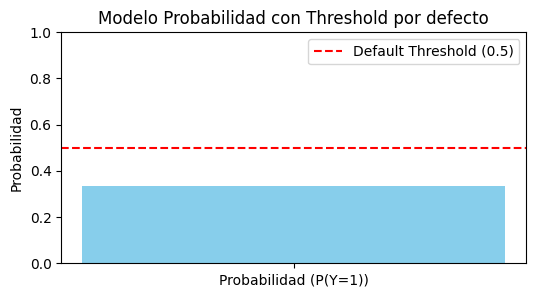

In [50]:
sample_record_scaled = X_test_scaled[0, :]
sample_record_original = X_test.iloc[0, :]
actual_class = y_test.iloc[0]

print(f"Registro (el primero en X_test):")
print(sample_record_original)
print(f"\nActual class for this record: {actual_class}")

# Paso 1: Calcular la combinación lineal (z-value)
# z = β0 + β1*x1 + β2*x2 + ... + βn*xn
z = intercept + np.sum(coefficients * sample_record_scaled)

print(f"\nPaso 1: Calcular el z-value (linear combination): {z:.4f}")

# Paso 2: Calcular la probabilidad usando la función logística
# P(Y=1|X) = 1 / (1 + e^(-z))
probability = 1 / (1 + np.exp(-z))

print(f"Paso 2: Calcular la probabilidad de Personal.Loan=1: {probability:.4f}")

# Step 3: Calcular basado en el threshold (por defecto es 0.5)
predicted_class = 1 if probability >= 0.5 else 0

print(f"Paso 3: Clasificación con un threshold (0.5): {predicted_class}")
print(f"Result: El modelo predice {'Personal.Loan' if predicted_class == 1 else 'No Personal.Loan'}.")


plt.figure(figsize=(6, 3))
plt.bar(['Probabilidad (P(Y=1))'], [probability], color='skyblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.ylim(0, 1)
plt.ylabel('Probabilidad')
plt.title('Modelo Probabilidad con Threshold por defecto')
plt.legend()
plt.show()

In [51]:
# Evaluacion del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.8573113207547169

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       724
           1       0.60      0.07      0.13       124

    accuracy                           0.86       848
   macro avg       0.73      0.53      0.53       848
weighted avg       0.82      0.86      0.81       848


Confusion Matrix:
[[718   6]
 [115   9]]


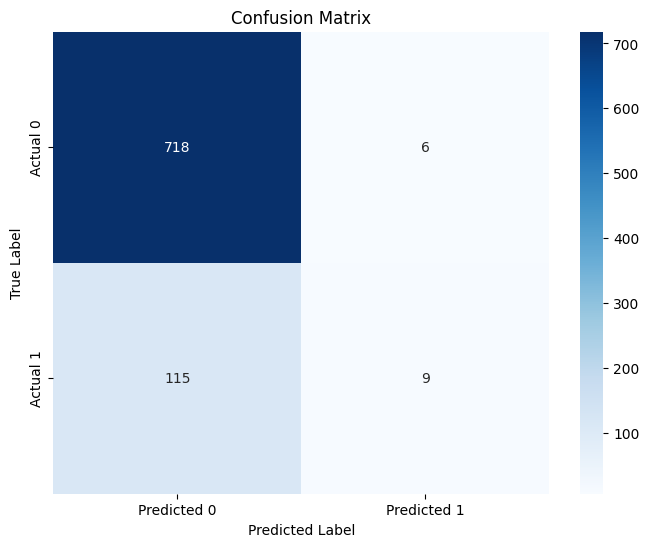

In [52]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

En este modelo tengo 718, verdaderos negativos, 6 falsos positivos, 115 falsos negativos y 9 verdaderos positivos, este numero de verdaderos negativos se debe reducir

**Modelo 2**:
voy a eliminar las variables



*   Education: porque tiene un coeficiente muy bajo es decir que no es tan util para este analisis
*   currentSmoker: -0.0177 porque en el anterior modelo tuvo un coeficiente muy bajo y tiene una alta correlacion con cigarettes per day que si tiene un coeficiente mas alto, es decir, es mas relevante para este analisis
*  BPMeds: 0.0426 porque tuvo un coeficiente bajo, es decir que no es tan relevante para el analisis
* prevalentStroke: 0.0735 tambien da un coeficiente bajo
*   prevalentHyp: 0.0904 este tambien da un coeficiente bajo y tiene alta correlacion con sysBP que tiene un coeficiente alto y puede servir mas para el analisis
*   diabetes: 0.0033 la diabetes segun este coeficiente tampoco nos sirve mucho para el analisis y esta tiene alta correlacion con la glucosa que tiene un coeficente alto
*   totChol: 0.0403 tambien muestra un coefciente bajo
*   diaBP: 0.0210 este tambien tiene un coeficiente bajo y tiene una alta correlacion con sysBP que tiene un coefciente mas alto, es decir, es mas relevante para el analisis
*   BMI: -0.0190 tambien tiene un coeficiente bajo entonces lo voy a borrar
*  heartRate: -0.0646 tambien tiene un coefciente mas bajo entonces lo voy a borrar






In [53]:
X = df.drop(['education','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes','totChol','diaBP','BMI','heartRate'], axis=1)
y = df['TenYearCHD']

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputación de valores faltantes
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Datos escalados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Modelo de regresion logistica
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train_scaled, y_train)

# Prediccion en el set de prueba
y_pred = model.predict(X_test_scaled)

# Evaluacion del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       724
           1       1.00      1.00      1.00       124

    accuracy                           1.00       848
   macro avg       1.00      1.00      1.00       848
weighted avg       1.00      1.00      1.00       848


Confusion Matrix:
[[724   0]
 [  0 124]]


In [54]:
# Get the intercept and coefficients from the trained model
intercept = model.intercept_[0]
coefficients = model.coef_[0]

print(f"Intercept (β0): {intercept:.4f}")
print("\nCoefficients (βi):")
# Assuming X_train_scaled is a numpy array, get feature names from original X_train
feature_names = X_train.columns

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")

print("\nThe logistic regression equation (in terms of log-odds) is:")
print(f"ln(P(Personal.Loan=1) / (1 - P(Personal.Loan=1))) = {intercept:.4f} + ", end="")

for i, (feature, coef) in enumerate(zip(feature_names, coefficients)):
    if i > 0:
        print(" + ", end="")
    print(f"({coef:.4f} * {feature})", end="")

print()

Intercept (β0): -5.4681

Coefficients (βi):
male: 0.0814
age: 0.2396
cigsPerDay: 0.0973
sysBP: 0.1653
glucose: 0.0735
TenYearCHD: 4.7008

The logistic regression equation (in terms of log-odds) is:
ln(P(Personal.Loan=1) / (1 - P(Personal.Loan=1))) = -5.4681 + (0.0814 * male) + (0.2396 * age) + (0.0973 * cigsPerDay) + (0.1653 * sysBP) + (0.0735 * glucose) + (4.7008 * TenYearCHD)


aca los coeficientes ya me estan dando mas altos, es decir que estas variables son mas releantes para el analisis de riesgo de enfermedad coronaria

Como opera el modelo clasificando un registro

Registro (el primero en X_test):
male            1.0
age            63.0
cigsPerDay      0.0
sysBP         148.0
glucose        86.0
TenYearCHD      0.0
Name: 3188, dtype: float64

Actual class for this record: 0

Paso 1: Calcular el z-value (linear combination): -6.9419
Paso 2: Calcular la probabilidad de Personal.Loan=1: 0.0010
Paso 3: Clasificación con un threshold (0.5): 0
Result: El modelo predice No Personal.Loan.


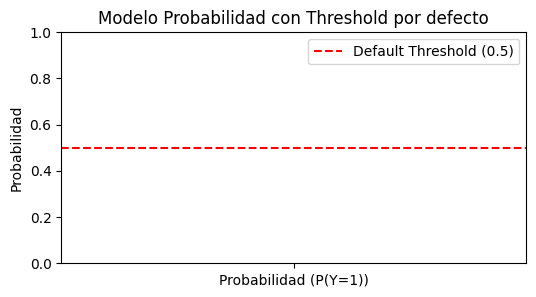

In [55]:
sample_record_scaled = X_test_scaled[0, :]
sample_record_original = X_test.iloc[0, :]
actual_class = y_test.iloc[0]

print(f"Registro (el primero en X_test):")
print(sample_record_original)
print(f"\nActual class for this record: {actual_class}")

# Paso 1: Calcular la combinación lineal (z-value)
# z = β0 + β1*x1 + β2*x2 + ... + βn*xn
z = intercept + np.sum(coefficients * sample_record_scaled)

print(f"\nPaso 1: Calcular el z-value (linear combination): {z:.4f}")

# Paso 2: Calcular la probabilidad usando la función logística
# P(Y=1|X) = 1 / (1 + e^(-z))
probability = 1 / (1 + np.exp(-z))

print(f"Paso 2: Calcular la probabilidad de Personal.Loan=1: {probability:.4f}")

# Step 3: Calcular basado en el threshold (por defecto es 0.5)
predicted_class = 1 if probability >= 0.5 else 0

print(f"Paso 3: Clasificación con un threshold (0.5): {predicted_class}")
print(f"Result: El modelo predice {'Personal.Loan' if predicted_class == 1 else 'No Personal.Loan'}.")


plt.figure(figsize=(6, 3))
plt.bar(['Probabilidad (P(Y=1))'], [probability], color='skyblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.ylim(0, 1)
plt.ylabel('Probabilidad')
plt.title('Modelo Probabilidad con Threshold por defecto')
plt.legend()
plt.show()

In [56]:
# Evaluacion del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       724
           1       1.00      1.00      1.00       124

    accuracy                           1.00       848
   macro avg       1.00      1.00      1.00       848
weighted avg       1.00      1.00      1.00       848


Confusion Matrix:
[[724   0]
 [  0 124]]


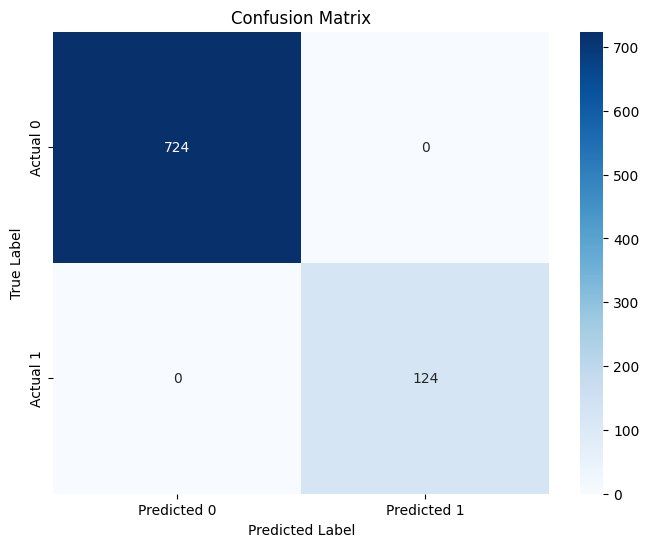

In [57]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

El numero de verdaderos negativos aumento, y hay unos valores que dan 0 y no deberia ser asi, tengo que mirar si hay alguna variable que no podia sacar para que el modelo mejore